# Analyse du Data Drift

Ce notebook compare les données de référence utilisées par le modèle
avec les données simulées de production.

## Objectifs

- analyser la qualité des données de production ;
- surveiller les probabilités et les décisions ;
- mesurer la latence de l’API ;
- détecter les variables ayant changé de distribution ;
- proposer des actions de surveillance ou de réentraînement.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PRODUCTION_PATH = BASE_DIR / "production_data" / "predictions_export.csv"

REFERENCE_CANDIDATES = [
    BASE_DIR / "data" / "processed" / "X_test_model.csv",
    BASE_DIR / "data" / "processed" / "home_credit_test_processed.csv",
    BASE_DIR / "data" / "processed" / "home_credit_train_processed.csv",
]

print("Données de production :", PRODUCTION_PATH)


Données de production : c:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\production_data\predictions_export.csv


## 1. Chargement des données de production

In [2]:
production_data = pd.read_csv(PRODUCTION_PATH)

print("Dimensions des données de production :", production_data.shape)

production_data.head()


Dimensions des données de production : (65, 312)


,id,request_id,timestamp,prediction,probability,threshold,decision,inference_time_ms,response_time_ms,status_code,...,PREV_CHANNEL_TYPE_STONE_MEAN,BURO_BB_STATUS_5_MEAN_MEAN,BURO_BB_STATUS_2_MEAN_MAX,PREV_NAME_GOODS_CATEGORY_CLOTHING_AND_ACCESSORIES_MEAN,BURO_BB_STATUS_0_MEAN_SUM,PREV_NAME_GOODS_CATEGORY_CONSUMER_ELECTRONICS_SUM,YEARS_BUILD_MEDI,PREV_AMT_CREDIT_MIN,PREV_NAME_SELLER_INDUSTRY_CONSUMER_ELECTRONICS_MEAN,BASEMENTAREA_AVG
0,1,65386219-47a9-4bb4-aa85-1d21cab5466e,2026-07-14T20:47:38.902926+00:00,0.0,0.2,0.48,Crédit accordé,3.5,0.082,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,f19f8766-3b3f-4fcc-bf2f-671f9fd8fbbd,2026-07-14T20:47:38.934317+00:00,1.0,0.8,0.48,Crédit refusé,4.0,0.065,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,pytest-success-9b620142-3dd2-4b91-b854-9efb78b...,2026-07-14T20:47:38.997604+00:00,0.0,0.2,0.48,Crédit accordé,3.5,5.000,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pytest-error-cb0f3e42-d03e-479b-a05c-de4e174c0c81,2026-07-14T20:47:39.016854+00:00,NaN,NaN,0.48,NaN,NaN,1.000,422,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,ea0059c7-1c10-4a30-9fc7-eeb268e45b22,2026-07-14T20:48:14.340692+00:00,0.0,0.2,0.48,Crédit accordé,3.5,0.143,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Qualité des données enregistrées

In [3]:
quality_report = pd.DataFrame({
    "type": production_data.dtypes.astype(str),
    "valeurs_manquantes": production_data.isna().sum(),
    "taux_manquant": production_data.isna().mean().round(4),
    "valeurs_uniques": production_data.nunique(dropna=False),
})

quality_report.sort_values(
    "taux_manquant",
    ascending=False,
).head(20)


,type,valeurs_manquantes,taux_manquant,valeurs_uniques
PREV_RATE_INTEREST_PRIVILEGED_MEAN,float64,63,0.9692,3
PREV_RATE_INTEREST_PRIVILEGED_MAX,float64,63,0.9692,3
PREV_RATE_INTEREST_PRIVILEGED_MIN,float64,63,0.9692,3
error_message,object,61,0.9385,3
PREV_DAYS_FIRST_DRAWING_MEAN,float64,56,0.8615,10
PREV_DAYS_FIRST_DRAWING_MIN,float64,56,0.8615,10
PREV_DAYS_FIRST_DRAWING_MAX,float64,56,0.8615,10
CC_CNT_DRAWINGS_ATM_CURRENT_MIN,float64,52,0.8000,2
CC_CNT_DRAWINGS_POS_CURRENT_MAX,float64,52,0.8000,8
CC_CNT_DRAWINGS_ATM_CURRENT_MAX,float64,52,0.8000,9


## 3. Synthèse opérationnelle de l’API

In [4]:
monitoring_summary = pd.Series({
    "nombre_appels": len(production_data),
    "nombre_erreurs": production_data["status_code"].ge(400).sum(),
    "taux_erreur": production_data["status_code"].ge(400).mean(),
    "temps_reponse_moyen_ms": production_data["response_time_ms"].mean(),
    "temps_reponse_max_ms": production_data["response_time_ms"].max(),
    "temps_inference_moyen_ms": production_data["inference_time_ms"].mean(),
    "probabilite_moyenne": production_data["probability"].mean(),
    "taux_refus": production_data["prediction"].mean(),
})

monitoring_summary


nombre_appels                65.000000
nombre_erreurs                4.000000
taux_erreur                   0.061538
temps_reponse_moyen_ms       14.692169
temps_reponse_max_ms        339.082000
temps_inference_moyen_ms      9.942967
probabilite_moyenne           0.411591
taux_refus                    0.409836
dtype: float64

## 4. Distribution des probabilités

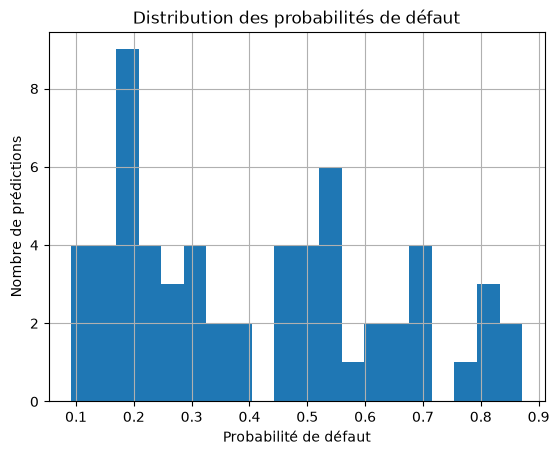

In [5]:
production_data["probability"].dropna().hist(bins=20)

plt.title("Distribution des probabilités de défaut")
plt.xlabel("Probabilité de défaut")
plt.ylabel("Nombre de prédictions")
plt.show()


## 5. Répartition des décisions

In [6]:
decision_counts = production_data["decision"].value_counts(
    dropna=False
)

decision_counts


decision
Crédit accordé    36
Crédit refusé     25
NaN                4
Name: count, dtype: int64

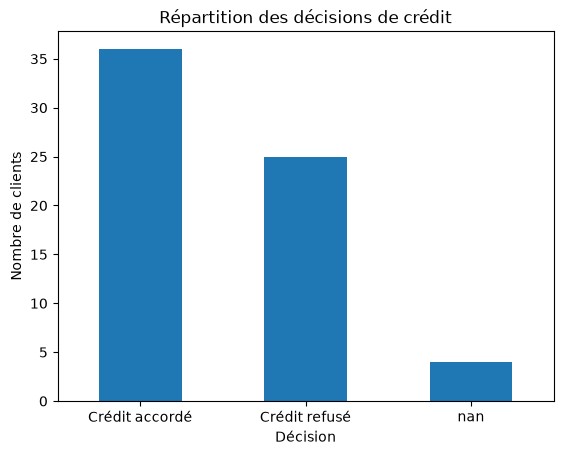

In [7]:
decision_counts.plot(kind="bar")

plt.title("Répartition des décisions de crédit")
plt.xlabel("Décision")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.show()


## 6. Analyse des temps de réponse

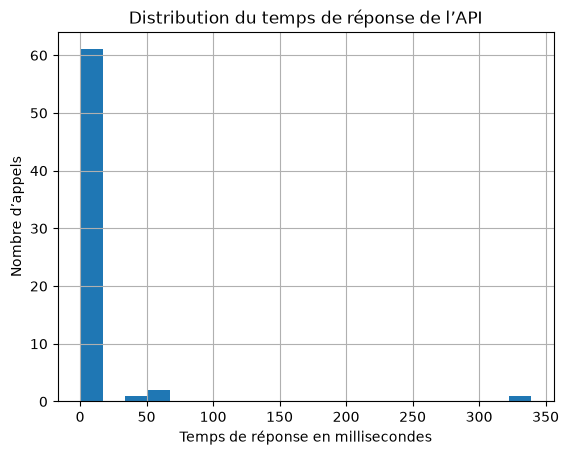

In [8]:
production_data["response_time_ms"].dropna().hist(bins=20)

plt.title("Distribution du temps de réponse de l’API")
plt.xlabel("Temps de réponse en millisecondes")
plt.ylabel("Nombre d’appels")
plt.show()


## 7. Chargement des données de référence

In [9]:
REFERENCE_PATH = next(
    (
        path
        for path in REFERENCE_CANDIDATES
        if path.exists()
    ),
    None,
)

if REFERENCE_PATH is None:
    raise FileNotFoundError(
        "Aucun fichier de référence compatible n’a été trouvé."
    )

reference_data = pd.read_csv(REFERENCE_PATH)

print("Fichier de référence :", REFERENCE_PATH)
print("Dimensions de référence :", reference_data.shape)


Fichier de référence : c:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\data\processed\home_credit_test_processed.csv
Dimensions de référence : (48744, 1610)


## 8. Sélection des variables comparables

In [10]:
technical_columns = {
    "id",
    "request_id",
    "timestamp",
    "prediction",
    "probability",
    "threshold",
    "decision",
    "inference_time_ms",
    "response_time_ms",
    "status_code",
    "error_message",
    "model_version",
}

production_features = production_data.drop(
    columns=[
        column
        for column in technical_columns
        if column in production_data.columns
    ],
    errors="ignore",
)

common_columns = [
    column
    for column in reference_data.columns
    if column in production_features.columns
]

print("Variables de production :", production_features.shape[1])
print("Variables comparables :", len(common_columns))


Variables de production : 300
Variables comparables : 300


## 9. Fonction Population Stability Index

Le PSI mesure l’écart entre une distribution de référence et une
distribution observée en production.


In [11]:
def calculate_psi(
    reference: pd.Series,
    production: pd.Series,
    bins: int = 10,
) -> float:
    reference = pd.to_numeric(
        reference,
        errors="coerce",
    ).dropna()

    production = pd.to_numeric(
        production,
        errors="coerce",
    ).dropna()

    if reference.empty or production.empty:
        return np.nan

    boundaries = np.unique(
        reference.quantile(
            np.linspace(0, 1, bins + 1)
        ).values
    )

    if len(boundaries) < 3:
        return np.nan

    boundaries[0] = -np.inf
    boundaries[-1] = np.inf

    reference_distribution = pd.cut(
        reference,
        bins=boundaries,
        include_lowest=True,
    ).value_counts(normalize=True, sort=False)

    production_distribution = pd.cut(
        production,
        bins=boundaries,
        include_lowest=True,
    ).value_counts(normalize=True, sort=False)

    reference_distribution = reference_distribution.replace(
        0,
        0.0001,
    )

    production_distribution = production_distribution.replace(
        0,
        0.0001,
    )

    psi = (
        (production_distribution - reference_distribution)
        * np.log(
            production_distribution / reference_distribution
        )
    ).sum()

    return float(psi)


## 10. Calcul du Data Drift

In [12]:
drift_results = []

for column in common_columns:
    if not pd.api.types.is_numeric_dtype(reference_data[column]):
        continue

    psi = calculate_psi(
        reference_data[column],
        production_features[column],
    )

    if pd.isna(psi):
        interpretation = "Non calculable"
    elif psi < 0.10:
        interpretation = "Pas de dérive significative"
    elif psi < 0.25:
        interpretation = "Dérive modérée"
    else:
        interpretation = "Dérive importante"

    drift_results.append({
        "variable": column,
        "psi": psi,
        "interpretation": interpretation,
    })

drift_report = pd.DataFrame(drift_results)

drift_report = drift_report.sort_values(
    "psi",
    ascending=False,
)

drift_report.head(20)


,variable,psi,interpretation
144,PREV_RATE_INTEREST_PRIVILEGED_MAX,3.851661,Dérive importante
145,PREV_RATE_INTEREST_PRIVILEGED_MEAN,3.798263,Dérive importante
143,PREV_RATE_INTEREST_PRIVILEGED_MIN,3.791490,Dérive importante
152,PREV_DAYS_FIRST_DRAWING_MAX,3.067390,Dérive importante
151,PREV_DAYS_FIRST_DRAWING_MIN,3.055067,Dérive importante
153,PREV_DAYS_FIRST_DRAWING_MEAN,3.049946,Dérive importante
297,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,2.497922,Dérive importante
25,LIVINGAPARTMENTS_AVG,2.018499,Dérive importante
38,LIVINGAPARTMENTS_MEDI,2.006939,Dérive importante
260,CC_MONTHS_BALANCE_MEAN,1.873941,Dérive importante


## 11. Variables présentant le plus de dérive

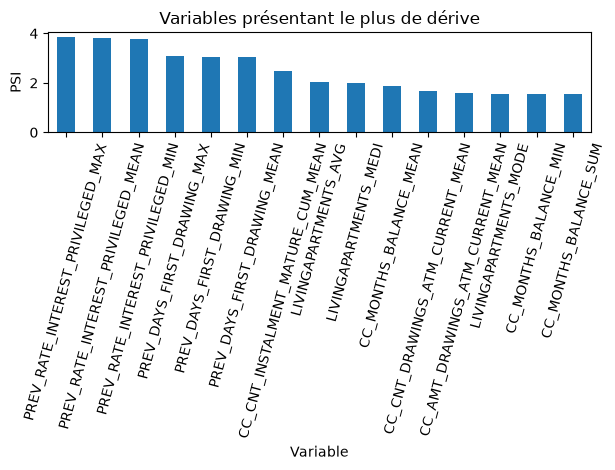

In [13]:
top_drift = (
    drift_report
    .dropna(subset=["psi"])
    .head(15)
)

top_drift.plot(
    x="variable",
    y="psi",
    kind="bar",
    legend=False,
)

plt.title("Variables présentant le plus de dérive")
plt.xlabel("Variable")
plt.ylabel("PSI")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 12. Nombre de variables par niveau de dérive

In [14]:
drift_report["interpretation"].value_counts()


interpretation
Dérive modérée                 118
Pas de dérive significative     77
Dérive importante               74
Non calculable                  31
Name: count, dtype: int64

## Conclusion

Les seuils d’interprétation utilisés sont :

- **PSI inférieur à 0,10** : pas de dérive significative ;
- **PSI entre 0,10 et 0,25** : dérive modérée à surveiller ;
- **PSI supérieur ou égal à 0,25** : dérive importante.

Une dérive des variables ne prouve pas automatiquement une baisse des
performances du modèle. Elle constitue cependant un signal nécessitant :

1. une surveillance renforcée ;
2. un contrôle des performances métier ;
3. une analyse des variables les plus touchées ;
4. un éventuel réentraînement du modèle si la dérive se maintient.

La taille de l’échantillon de production simulé doit également être prise
en compte. Plus le nombre de prédictions est élevé, plus l’analyse du
drift devient fiable.
